<a href="https://colab.research.google.com/github/Sudip-2901/Analytics-Project/blob/main/Olist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2


# Olist E-Commerce Analysis
## Phase 1 — Environment Setup

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Tools:** Python, pandas, matplotlib, seaborn  
**Goal:** Load, clean, and analyse 9 relational tables to extract business insights.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
path = "/content/drive/MyDrive/Olist/"

orders       = pd.read_csv(path + "olist_orders_dataset.csv")
customers    = pd.read_csv(path + "olist_customers_dataset.csv")
order_items  = pd.read_csv(path + "olist_order_items_dataset.csv")
payments     = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews      = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products     = pd.read_csv(path + "olist_products_dataset.csv")
sellers      = pd.read_csv(path + "olist_sellers_dataset.csv")
category_map = pd.read_csv(path + "product_category_name_translation.csv")
geo          = pd.read_csv(path + "olist_geolocation_dataset.csv")

print("All tables loaded.")

All tables loaded.


In [7]:
# Step 1: orders + customers
df = orders.merge(customers, on="customer_id", how="left")

# Step 2: + order_items (bridge to products and sellers)
df = df.merge(order_items, on="order_id", how="left")

# Step 3: + products
df = df.merge(products, on="product_id", how="left")

# Step 4: + category translation
df = df.merge(category_map, on="product_category_name", how="left")

# Step 5: + sellers
df = df.merge(sellers, on="seller_id", how="left")

# Step 6: + payments (use aggregated version!)
df = df.merge(payments, on="order_id", how="left")

# Step 7: + reviews
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

# Check what you've built
print(df.shape)
print(df.columns.tolist())

(119143, 35)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_score']


**we used how="left" throughout. This means we keep all rows from orders even if there's no match on the right side. A missing product or seller shouldn't delete the order from our analysis.**

**Orders Data Cleaning**


In [8]:
##Converting string formats to datetime.
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
##The errors="coerce" parameter is important — if a value can't be parsed as a date,
##it becomes NaT (Not a Time, pandas' version of NaN for dates) instead of crashing your code.
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
##You'll see the nulls are mostly non-delivered orders
print(orders["order_approved_at"].isnull().sum())
print(orders[orders["order_approved_at"].isnull()]["order_status"].value_counts())

160
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64


You'll see the nulls are mostly non-delivered orders. The right response isn't to fill or drop — it's to flag:

In [10]:
#You'll see the nulls are mostly non-delivered orders.
#nulls in order_approved_at, keep rows, flag with boolean is_approved column
#This gives you a 1/0 column you can use later in ML as a feature.
orders["is_approved"] = orders["order_approved_at"].notnull().astype(int)

In [11]:
##These nulls are not errors, they're orders that were never delivered.
##Don't fill, don't drop. Instead add a flag column so you can filter cleanly later:
#The orders missing a delivered date are cancelled, shipped, or processing orders — they're valid business data.
orders["is_delivered"] = (orders["order_status"] == "delivered").astype(int)

In [12]:
#Engineer delivery_days
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

In [13]:
print(orders["delivery_days"].describe().round(1))
print("Nulls in delivery_days:", orders["delivery_days"].isnull().sum())
#The nulls here are expected — non-delivered orders have no delivery date

count    96476.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64
Nulls in delivery_days: 2965


In [14]:
#Negative means the order arrived early, positive means it arrived late
#.dt.days extracts the integer number of days from the resulting timedelta.
#Without it, you'd get a timedelta object (3 days 04:32:11) which is harder to use in analysis and ML.
orders["delay_vs_estimate"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

In [15]:
# How many orders were late vs early?
late  = (orders["delay_vs_estimate"] > 0).sum()
early = (orders["delay_vs_estimate"] <= 0).sum()
print(f"Late orders:  {late:,}")
print(f"Early orders: {early:,}")

Late orders:  6,535
Early orders: 89,941


In [16]:
#Always end every table's cleaning block with a verification cell.
print("orders shape:", orders.shape)
print("\nNull counts:")
print(orders.isnull().sum())
print("\nNew columns preview:")
orders[["order_purchase_timestamp", "delivery_days", "delay_vs_estimate", "is_delivered", "is_approved"]].head(5)

orders shape: (99441, 12)

Null counts:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
is_approved                         0
is_delivered                        0
delivery_days                    2965
delay_vs_estimate                2965
dtype: int64

New columns preview:


,order_purchase_timestamp,delivery_days,delay_vs_estimate,is_delivered,is_approved
0,2017-10-02 10:56:33,8.0,-8.0,1,1
1,2018-07-24 20:41:37,13.0,-6.0,1,1
2,2018-08-08 08:38:49,9.0,-18.0,1,1
3,2017-11-18 19:28:06,13.0,-13.0,1,1
4,2018-02-13 21:18:39,2.0,-10.0,1,1


In [17]:
# Time-based features from purchase timestamp
orders["purchase_month"]      = orders["order_purchase_timestamp"].dt.month
orders["purchase_dayofweek"]  = orders["order_purchase_timestamp"].dt.dayofweek  # 0=Mon, 6=Sun
orders["purchase_hour"]       = orders["order_purchase_timestamp"].dt.hour
orders["purchase_year"]       = orders["order_purchase_timestamp"].dt.year

# Check distributions
print("Orders by hour of day:")
print(orders["purchase_hour"].value_counts().sort_index())

Orders by hour of day:
purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64


**Purchase hour and day of week are strong predictors in e-commerce — people buy differently on weekday mornings vs. weekend evenings. These will be useful features in ML and interesting patterns in EDA.**

In [18]:
##already have delay_vs_estimate as a continuous number. But for classification modelling
##and for EDA charts, a simple binary flag is cleaner.
orders["is_late"] = (orders["delay_vs_estimate"] > 0).astype(int)
# How many delivered orders were late?
delivered = orders[orders["is_delivered"] == 1]
late_rate = delivered["is_late"].mean() * 100
print(f"Late delivery rate: {late_rate:.1f}%")

Late delivery rate: 6.8%


In [19]:
##The gap between purchase and payment approval is a signal of order friction.
orders["approval_time_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600  # convert to hours

print(orders["approval_time_hours"].describe().round(1))

count    99281.0
mean        10.4
std         26.0
min          0.0
25%          0.2
50%          0.3
75%         14.6
max       4509.2
Name: approval_time_hours, dtype: float64


In [20]:
print("orders shape:", orders.shape)
print("\nAll columns now:")
print(orders.columns.tolist())
print("\nSample of engineered columns:")
orders[[
    "order_purchase_timestamp", "purchase_month", "purchase_dayofweek",
    "purchase_hour", "is_late", "approval_time_hours",
    "delivery_days", "delay_vs_estimate"
]].head(5)

orders shape: (99441, 18)

All columns now:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_approved', 'is_delivered', 'delivery_days', 'delay_vs_estimate', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_year', 'is_late', 'approval_time_hours']

Sample of engineered columns:


,order_purchase_timestamp,purchase_month,purchase_dayofweek,purchase_hour,is_late,approval_time_hours,delivery_days,delay_vs_estimate
0,2017-10-02 10:56:33,10,0,10,0,0.178333,8.0,-8.0
1,2018-07-24 20:41:37,7,1,20,0,30.713889,13.0,-6.0
2,2018-08-08 08:38:49,8,2,8,0,0.276111,9.0,-18.0
3,2017-11-18 19:28:06,11,5,19,0,0.298056,13.0,-13.0
4,2018-02-13 21:18:39,2,1,21,0,1.030556,2.0,-10.0


**Customer Data Cleaning**

**customer_id** is a **per-order ID**. The same person gets a new **customer_id** every time they place a new order. It's what joins customers → orders.
**customer_unique_id** is the true person identifier. Use this whenever you want to analyse returning customers, repeat purchase rate, or churn.

In [21]:
print("Unique customer_id values:       ", customers["customer_id"].nunique())
print("Unique customer_unique_id values:", customers["customer_unique_id"].nunique())

Unique customer_id values:        99441
Unique customer_unique_id values: 96096


In [22]:
##Standardise city names
##Together they collapse variants like "São Paulo", "são paulo", "  SAO PAULO  " into one.
customers["customer_city"] = customers["customer_city"].str.strip().str.title()
print("Unique cities after standardisation:", customers["customer_city"].nunique())

Unique cities after standardisation: 4119


In [23]:
print("Unique customer_id:        ", customers["customer_id"].nunique())
print("Unique customer_unique_id: ", customers["customer_unique_id"].nunique())

Unique customer_id:         99441
Unique customer_unique_id:  96096


In [24]:
repeat_customers = (
    customers.groupby("customer_unique_id")
    .size()
    .reset_index(name="order_count")
)
print("Repeat customer breakdown:")
print(repeat_customers["order_count"].value_counts().sort_index().head(8))

Repeat customer breakdown:
order_count
1    93099
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
Name: count, dtype: int64


In [25]:
print("customers shape:", customers.shape)
print("\nNull counts:")
print(customers.isnull().sum())
print("\nSample:")
customers.head(3)

customers shape: (99441, 5)

Null counts:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Sample:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,Sao Bernardo Do Campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,Sao Paulo,SP


Let's use **customer_unique_id** to create a simple flag that says: is this person a one-time buyer or a repeat buyer

In [26]:
# Count how many orders each unique customer has placed
order_counts = (
    customers.groupby("customer_unique_id")
    .size()
    .reset_index(name="customer_order_count")
)
##This becomes a useful feature later, both for
##EDA ("what % of revenue comes from repeat customers?") and for the churn prediction model.
# Merge back onto the customers table
customers = customers.merge(order_counts, on="customer_unique_id", how="left")

# Create a binary repeat customer flag
customers["is_repeat_customer"] = (customers["customer_order_count"] > 1).astype(int)
print(customers["is_repeat_customer"].value_counts())
print(f"\nRepeat customer rate: {customers['is_repeat_customer'].mean()*100:.1f}%")


is_repeat_customer
0    93099
1     6342
Name: count, dtype: int64

Repeat customer rate: 6.4%


**Brazil's 27 states are in the data, but for analysis and modelling, grouping into 5 macro-regions is often more meaningful — fewer categories, cleaner charts, and regions have genuine economic differences that matter for delivery times and purchase behaviour.**

In [27]:
region_map = {
    # Southeast
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    # South
    "PR": "South", "SC": "South", "RS": "South",
    # Northeast
    "BA": "Northeast", "PE": "Northeast", "CE": "Northeast", "MA": "Northeast",
    "PB": "Northeast", "RN": "Northeast", "AL": "Northeast", "SE": "Northeast",
    "PI": "Northeast",
    # North
    "AM": "North", "PA": "North", "RO": "North", "AC": "North",
    "AP": "North", "RR": "North", "TO": "North",
    # Central-West
    "MT": "Central-West", "MS": "Central-West", "GO": "Central-West", "DF": "Central-West"
}

customers["customer_region"] = customers["customer_state"].map(region_map)
# Check for any unmapped states
print("Unmapped states:", customers["customer_region"].isnull().sum())
print("\nRegion distribution:")
print(customers["customer_region"].value_counts())

Unmapped states: 0

Region distribution:
customer_region
Southeast       68266
South           14148
Northeast        9394
Central-West     5782
North            1851
Name: count, dtype: int64


You might wonder: should we add age, income, gender? No — Olist doesn't have that data. Should we parse the city name to extract more structure? No — the zip code prefix is a more reliable geographic unit than city names which have encoding issues in Brazilian Portuguese.

In [28]:
print("customers shape:", customers.shape)
print("\nNew columns:")
customers[["customer_unique_id", "customer_order_count",
           "is_repeat_customer", "customer_region"]].head(8)

customers shape: (99441, 8)

New columns:


,customer_unique_id,customer_order_count,is_repeat_customer,customer_region
0,861eff4711a542e4b93843c6dd7febb0,1,0,Southeast
1,290c77bc529b7ac935b93aa66c333dc3,1,0,Southeast
2,060e732b5b29e8181a18229c7b0b2b5e,1,0,Southeast
3,259dac757896d24d7702b9acbbff3f3c,1,0,Southeast
4,345ecd01c38d18a9036ed96c73b8d066,1,0,Southeast
5,4c93744516667ad3b8f1fb645a3116a4,2,1,South
6,addec96d2e059c80c30fe6871d30d177,1,0,Southeast
7,57b2a98a409812fe9618067b6b8ebe4f,1,0,Southeast


In [29]:
# --- ORDERS — ADDITIONAL ENGINEERING ---
# Time-based features from purchase timestamp
orders["purchase_month"]      = orders["order_purchase_timestamp"].dt.month
orders["purchase_dayofweek"]  = orders["order_purchase_timestamp"].dt.dayofweek  # 0=Mon, 6=Sun
orders["purchase_hour"]       = orders["order_purchase_timestamp"].dt.hour
orders["purchase_year"]       = orders["order_purchase_timestamp"].dt.year

# Check distributions
print("Orders by hour of day:")
print(orders["purchase_hour"].value_counts().sort_index())

# Purchase hour and day of week are strong predictors in e-commerce,
# people buy differently on weekday mornings vs. weekend evenings.

Orders by hour of day:
purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64


**We already have delay_vs_estimate as a continuous number. But for classification modelling and for EDA charts, a simple binary flag is cleaner.**


In [30]:
# Binary late delivery flag (only meaningful for delivered orders)
orders["is_late"] = (orders["delay_vs_estimate"] > 0).astype(int)

# How many delivered orders were late?
delivered = orders[orders["is_delivered"] == 1]
late_rate = delivered["is_late"].mean() * 100
print(f"Late delivery rate: {late_rate:.1f}%")

Late delivery rate: 6.8%


**Note we check the late rate only on delivered orders, non-delivered orders have null delay_vs_estimate, which evaluates to False in the comparison, giving a misleadingly low late rate if we don't filter.**

In [31]:
orders["approval_time_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600  # convert to hours

print(orders["approval_time_hours"].describe().round(1))

count    99281.0
mean        10.4
std         26.0
min          0.0
25%          0.2
50%          0.3
75%         14.6
max       4509.2
Name: approval_time_hours, dtype: float64


In [32]:
print("orders shape:", orders.shape)
print("\nAll columns now:")
print(orders.columns.tolist())
print("\nSample of engineered columns:")
orders[[
    "order_purchase_timestamp", "purchase_month", "purchase_dayofweek",
    "purchase_hour", "is_late", "approval_time_hours",
    "delivery_days", "delay_vs_estimate"
]].head(5)

orders shape: (99441, 18)

All columns now:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_approved', 'is_delivered', 'delivery_days', 'delay_vs_estimate', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_year', 'is_late', 'approval_time_hours']

Sample of engineered columns:


,order_purchase_timestamp,purchase_month,purchase_dayofweek,purchase_hour,is_late,approval_time_hours,delivery_days,delay_vs_estimate
0,2017-10-02 10:56:33,10,0,10,0,0.178333,8.0,-8.0
1,2018-07-24 20:41:37,7,1,20,0,30.713889,13.0,-6.0
2,2018-08-08 08:38:49,8,2,8,0,0.276111,9.0,-18.0
3,2017-11-18 19:28:06,11,5,19,0,0.298056,13.0,-13.0
4,2018-02-13 21:18:39,2,1,21,0,1.030556,2.0,-10.0


They measure the same thing but serve different purposes:

delay_vs_estimate (continuous) — use this for EDA. "How many days late on average in the Northeast vs Southeast?" needs a number, not a flag.
is_late (binary) — use this for classification ML and for simple business reporting. "What % of orders were late?" is cleaner as a percentage of is_late == 1.

1. **Purchase hours — the pattern is exactly what you'd expect from consumer behaviour: dead between 2–5am, ramps up sharply from 8am, peaks in the afternoon (16–17h), stays high through the evening. This is a genuinely useful ML feature.**
2. **Late delivery rate: 6.8% — only 1 in 15 delivered orders arrived late. Combined with the earlier finding that estimated delivery averages 23 days but actual delivery averages 12 days, Olist consistently sets conservative estimates and beats them. That's a deliberate business strategy — under-promise, over-deliver.**

**Order Items data cleaning**

In [33]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)

print(order_items.dtypes)

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


In [34]:
# How many items per order?
items_per_order = order_items.groupby("order_id")["order_item_id"].max()
print("Items per order distribution:")
print(items_per_order.value_counts().sort_index().head(10))
print(f"\nMax items in a single order: {items_per_order.max()}")

Items per order distribution:
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
Name: count, dtype: int64

Max items in a single order: 21


**Outlier investigation on price and freight**

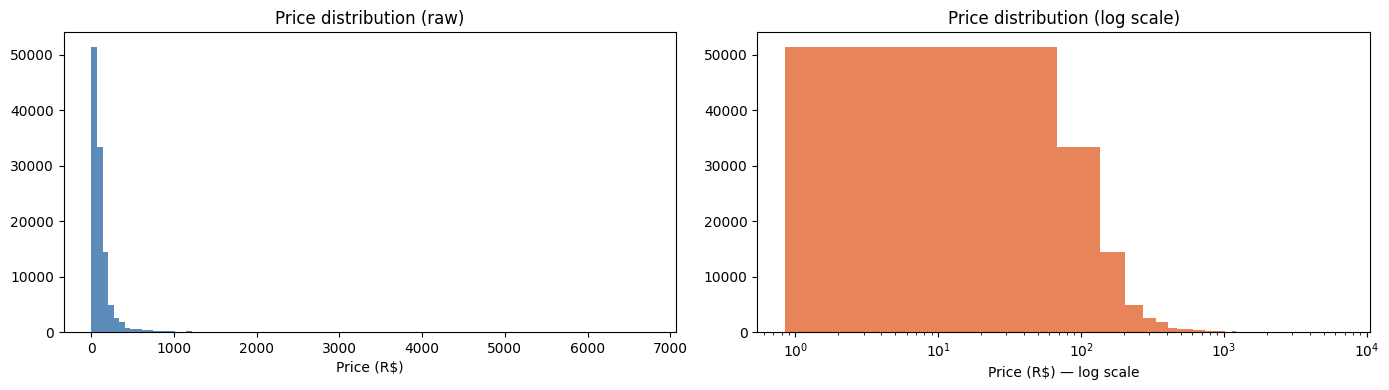

Q1: R$39.90
Q3: R$134.90
IQR: R$95.00
Upper fence (Q3 + 1.5×IQR): R$277.40
Rows above upper fence: 8,427


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Price distribution — log scale because of extreme right tail
axes[0].hist(order_items["price"], bins=100, edgecolor="none", color="#5C8DBA")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price (R$)")

# Same with log scale to see the shape better
axes[1].hist(order_items["price"], bins=100, edgecolor="none", color="#E8845A")
axes[1].set_xscale("log")
axes[1].set_title("Price distribution (log scale)")
axes[1].set_xlabel("Price (R$) — log scale")

plt.tight_layout()
plt.show()

# IQR-based outlier thresholds
Q1 = order_items["price"].quantile(0.25)
Q3 = order_items["price"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Q1: R${Q1:.2f}")
print(f"Q3: R${Q3:.2f}")
print(f"IQR: R${IQR:.2f}")
print(f"Upper fence (Q3 + 1.5×IQR): R${upper_fence:.2f}")
print(f"Rows above upper fence: {(order_items['price'] > upper_fence).sum():,}")

**Flag outliers, don't drop them**

In [36]:
# Flag price outliers
order_items["is_price_outlier"] = (order_items["price"] > upper_fence).astype(int)

# Same for freight
Q1_f = order_items["freight_value"].quantile(0.25)
Q3_f = order_items["freight_value"].quantile(0.75)
IQR_f = Q3_f - Q1_f
upper_fence_f = Q3_f + 1.5 * IQR_f

order_items["is_freight_outlier"] = (order_items["freight_value"] > upper_fence_f).astype(int)

print(f"Price outlier rows:   {order_items['is_price_outlier'].sum():,}")
print(f"Freight outlier rows: {order_items['is_freight_outlier'].sum():,}")

Price outlier rows:   8,427
Freight outlier rows: 11,613


Why flag instead of drop or cap? Because a R$6,735 item might be a genuine high-value electronics purchase — dropping it would distort my revenue analysis. During ML we have make a deliberate decision to include or exclude outliers based on what we're predicting.